## **Rep. 4. Checkpoint 3. Estrategias II**
#### Paola A. Figueroa Álvarez
#### 13/abril/2026

## **Instrucciones**
Toma el código desarrollado en clase para las cuatro estrategias neutrales (butterfly, iron condor, covered call y protective put) y ejecútalo en tu notebook usando los precios mid reales de SPY con vencimiento 2026-04-17, obtenidos dinámicamente con yfinance (siguiendo el mismo patrón visto en clase). No necesitas escribir código nuevo: la actividad consiste en correr el código de clase con datos actualizados y presentar:

-  El payoff diagram del butterfly spread
-  El payoff diagram del iron condor
-   El payoff diagram del covered call
- El payoff diagram del protective put
- Una tabla resumen con prima neta (pagada o cobrada), ganancia máxima, pérdida máxima y break-even(s) de cada estrategia (los valores ya se imprimen en el código de clase, basta con consolidarlos en una tabla)

## **Librerías**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

## **Funciones**

In [2]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## **Precios reales**

In [3]:
spy = yf.Ticker("SPY")
S0 = spy.history(period="1d")["Close"].iloc[-1]

exp = "2026-04-17"
opt_chain = spy.option_chain(exp)

calls = opt_chain.calls.copy()
puts  = opt_chain.puts.copy()

# Limpiar datos 
calls = calls.dropna(subset=["bid", "ask"])
puts  = puts.dropna(subset=["bid", "ask"])

# Precio mid
calls["mid"] = (calls["bid"] + calls["ask"]) / 2
puts["mid"]  = (puts["bid"] + puts["ask"]) / 2

# rango de precios
S_range = np.linspace(S0 * 0.7, S0 * 1.3, 500)

print(f"Precio actual SPY: {S0:.2f}")

Precio actual SPY: 694.46


## **Estructura Base**

In [ ]:
K2   = round(S0)
step = 10  # alas de las estrategias
K1 = K2 - step
K3 = K2 + step

K_pl = K2 - 2*step
K_ps = K2 - step
K_cs = K2 + step
K_cl = K2 + 2*step

def get_call_mid(K, df=calls):
    row = df[df["strike"] == K]
    if row.empty:
        raise ValueError(f"No hay call con strike {K} en la cadena para {exp}")
    return float(row["mid"].values[0])

def get_put_mid(K, df=puts):
    row = df[df["strike"] == K]
    if row.empty:
        raise ValueError(f"No hay put con strike {K} en la cadena para {exp}")
    return float(row["mid"].values[0])

## **Estrategias**

### **Butterfly**

Prima neta pagada : $4.23
Ganancia máxima   : $5.77  (si ST =694)
Pérdida máxima    : $-4.23
Break-even inf.   : $688.23  |  sup.: $699.77


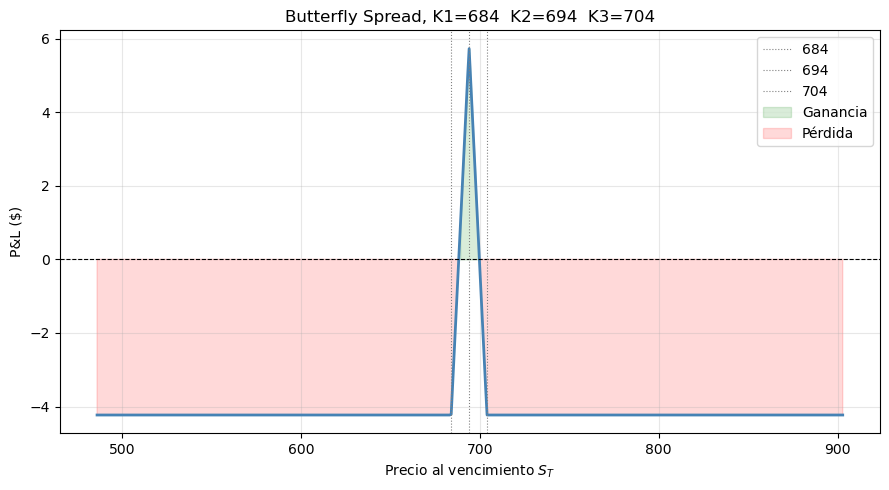

In [5]:
K1 = K_ps      
K2 = K2          
K3 = K_cs 

C1 = get_call_mid(K1)
C2 = get_call_mid(K2)
C3 = get_call_mid(K3)

legs_butterfly = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -2},
    {'tipo': 'call', 'K': K3, 'prima': C3, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_butterfly)
prima_neta = C1 - 2*C2 + C3

print(f"Prima neta pagada : ${prima_neta:.2f}")
print(f"Ganancia máxima   : ${(K2 - K1) - prima_neta:.2f}  (si ST ={K2})")
print(f"Pérdida máxima    : ${-prima_neta:.2f}")
print(f"Break-even inf.   : ${K1 + prima_neta:.2f}  |  sup.: ${K3 - prima_neta:.2f}")

graficar_estrategia(
    S_range, pnl,
    f'Butterfly Spread, K1={K1}  K2={K2}  K3={K3}',
    K_lines=[(K1,f'{K1}'),(K2,f'{K2}'),(K3,f'{K3}')]
)

### **Iron Condor**

S0 = 694.46
K_pl=674  put long  prima=0.51
K_ps=684  put short prima=1.24
K_cs=704  call short prima=0.41
K_cl=714  call long  prima=0.07

Prima cobrada     : $1.08  (ganancia máxima)
Pérdida máxima    : $8.92
Zona de ganancia  : [684, 704]


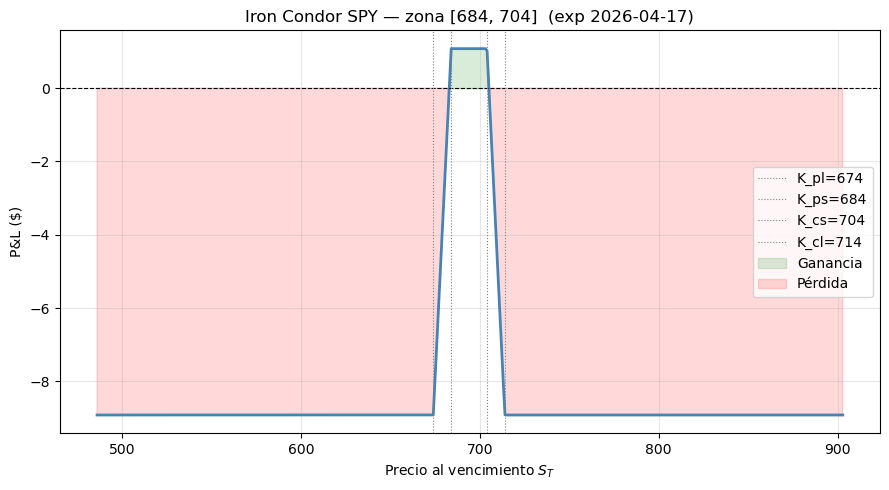

In [7]:
K_ps = K2 - step   
K_pl = K_ps - step        
K_cs = K2 + step        
K_cl = K_cs + step        

P_l = get_put_mid(K_pl)
P_s = get_put_mid(K_ps)
C_s = get_call_mid(K_cs)
C_l = get_call_mid(K_cl)

print(f"S0 = {S0:.2f}")
print(f"K_pl={K_pl}  put long  prima={P_l:.2f}")
print(f"K_ps={K_ps}  put short prima={P_s:.2f}")
print(f"K_cs={K_cs}  call short prima={C_s:.2f}")
print(f"K_cl={K_cl}  call long  prima={C_l:.2f}")

legs_condor = [
    {'tipo': 'put',  'K': K_pl, 'prima': P_l, 'posicion': +1},
    {'tipo': 'put',  'K': K_ps, 'prima': P_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cs, 'prima': C_s, 'posicion': -1},
    {'tipo': 'call', 'K': K_cl, 'prima': C_l, 'posicion': +1},
]
pnl = payoff_estrategia(S_range, legs_condor)
prima_cobrada = (P_s - P_l) + (C_s - C_l)
perdida_max   = (K_ps - K_pl) - prima_cobrada

print(f"\nPrima cobrada     : ${prima_cobrada:.2f}  (ganancia máxima)")
print(f"Pérdida máxima    : ${perdida_max:.2f}")
print(f"Zona de ganancia  : [{K_ps}, {K_cs}]")
graficar_estrategia(S_range, pnl,
                    f'Iron Condor SPY — zona [{K_ps}, {K_cs}]  (exp {exp})',
                    K_lines=[(K_pl, f'K_pl={K_pl}'), (K_ps, f'K_ps={K_ps}'),
                             (K_cs, f'K_cs={K_cs}'), (K_cl, f'K_cl={K_cl}')])

### **Covered Call**

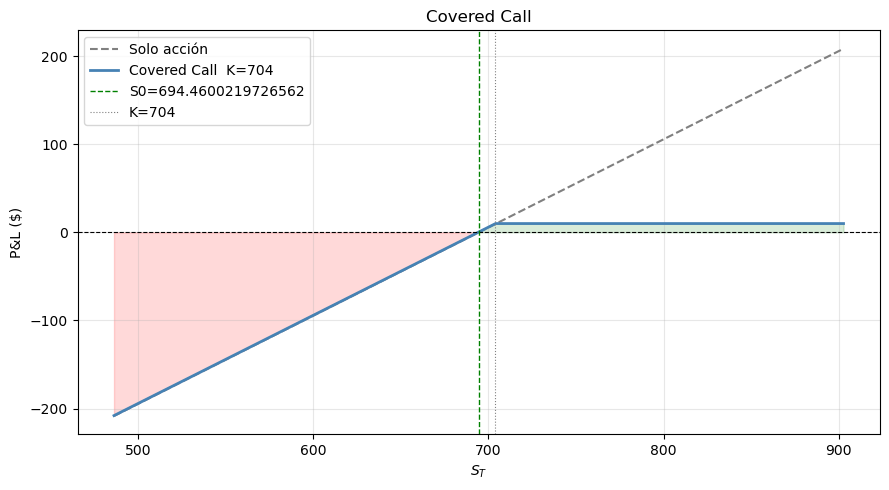

Ganancia máxima : $9.95  (si ST ≥ 704)
Break-even      : $694.05


In [8]:
K_cc = K_cs
C_cc = get_call_mid(K_cc)

# PnL
pnl_accion  = S_range - S0
pnl_covered = pnl_accion + (-np.maximum(S_range - K_cc, 0) + C_cc)

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))

plt.plot(S_range, pnl_accion,
         color='gray', linewidth=1.5,
         linestyle='--', label='Solo acción')

plt.plot(S_range, pnl_covered,
         color='steelblue', linewidth=2,
         label=f'Covered Call  K={K_cc}')

plt.axhline(0,
            color='black', linewidth=0.8, linestyle='--')

plt.axvline(S0,
            color='green', linewidth=1.0, linestyle='--',
            label=f'S0={S0}')

plt.axvline(K_cc,
            color='gray', linewidth=0.8, linestyle=':',
            label=f'K={K_cc}')

plt.fill_between(S_range, pnl_covered, 0,
                 where=(pnl_covered > 0),
                 alpha=0.15, color='green')

plt.fill_between(S_range, pnl_covered, 0,
                 where=(pnl_covered < 0),
                 alpha=0.15, color='red')

plt.xlabel('$S_T$')
plt.ylabel('P&L ($)')
plt.title('Covered Call')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ganancia máxima : ${K_cc - S0 + C_cc:.2f}  (si ST ≥ {K_cc})")
print(f"Break-even      : ${S0 - C_cc:.2f}")

### **Protective Put**

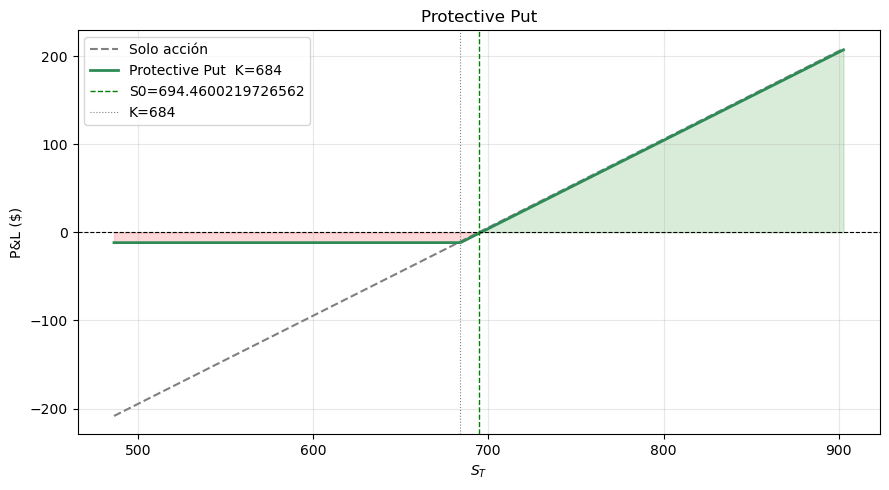

Pérdida máxima : $-11.70  (si ST ≤ 684)
Break-even     : $695.70


In [9]:
K_pp = K_ps
P_pp = get_put_mid(K_pp)
pnl_protective = pnl_accion + (np.maximum(K_pp - S_range, 0) - P_pp)
plt.figure(figsize=(9, 5))

plt.plot(S_range, pnl_accion,
         color='gray', linewidth=1.5,
         linestyle='--', label='Solo acción')

plt.plot(S_range, pnl_protective,
         color='seagreen', linewidth=2,
         label=f'Protective Put  K={K_pp}')

plt.axhline(0,
            color='black', linewidth=0.8, linestyle='--')

plt.axvline(S0,
            color='green', linewidth=1.0, linestyle='--',
            label=f'S0={S0}')

plt.axvline(K_pp,
            color='gray', linewidth=0.8, linestyle=':',
            label=f'K={K_pp}')


plt.fill_between(S_range, pnl_protective, 0,
                 where=(pnl_protective > 0),
                 alpha=0.15, color='green')

plt.fill_between(S_range, pnl_protective, 0,
                 where=(pnl_protective < 0),
                 alpha=0.15, color='red')

plt.xlabel('$S_T$')
plt.ylabel('P&L ($)')
plt.title('Protective Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Pérdida máxima : ${-(S0 - K_pp + P_pp):.2f}  (si ST ≤ {K_pp})")
print(f"Break-even     : ${S0 + P_pp:.2f}")

### **Tabla Resumen**

In [10]:
tabla = pd.DataFrame([
    {
        "Estrategia": "Butterfly",
        "Prima Neta": prima_neta,
        "Ganancia Máxima": (K2 - K1) - prima_neta,
        "Pérdida Máxima": -prima_neta,
        "Break-even(s)": f"{K1 + prima_neta:.2f} / {K3 - prima_neta:.2f}"
    },
    {
        "Estrategia": "Iron Condor",
        "Prima Neta": prima_cobrada,
        "Ganancia Máxima": prima_cobrada,
        "Pérdida Máxima": perdida_max,
        "Break-even(s)": f"{K_ps - prima_cobrada:.2f} / {K_cs + prima_cobrada:.2f}"
    },
    {
        "Estrategia": "Covered Call",
        "Prima Neta": C_cc,
        "Ganancia Máxima": K_cc - S0 + C_cc,
        "Pérdida Máxima": "Ilimitada (↓ S)",
        "Break-even(s)": f"{S0 - C_cc:.2f}"
    },
    {
        "Estrategia": "Protective Put",
        "Prima Neta": -P_pp,
        "Ganancia Máxima": "Ilimitada (↑ S)",
        "Pérdida Máxima": -(S0 - K_pp + P_pp),
        "Break-even(s)": f"{S0 + P_pp:.2f}"
    }
])

tabla

,Estrategia,Prima Neta,Ganancia Máxima,Pérdida Máxima,Break-even(s)
0,Butterfly,4.230,5.77,-4.23,688.23 / 699.77
1,Iron Condor,1.080,1.08,8.92,682.92 / 705.08
2,Covered Call,0.415,9.954978,Ilimitada (↓ S),694.05
3,Protective Put,-1.240,Ilimitada (↑ S),-11.700022,695.70


### **Preguntas**

- **1.- Con el S0 actual, ¿cuál de las cuatro estrategias está mejor posicionada (más cerca de su zona de máxima ganancia)? ¿Qué visión de mercado tendría que tener un trader para elegirla hoy?**
    - El iron condor está mejor posicionado, ya que So se ubica dentro de su zona de máxima ganancia [Kps, Kcs]. Esto implica una visión neutral, esperando baja volatilidad y que el precio permanezca en rango hasta el vencimiento.

- **2.- Un iron condor cobra prima desde el inicio. ¿Eso lo hace una estrategia sin riesgo? ¿Cuál es el peor escenario para tu condor y cuándo ocurre? Calcula la pérdida máxima exacta con tus datos.**
    - El Iron Condor no es libre de riesgo, pues pierde si St sale del rango [Kps, Kcs]. El peor escenario ocurre en los extremos, donde St<Kpl ó St>Kcl), donde la pérdida máxima sería (Kps -Kcs) - prima cobrada. En el caso de mis datos, la pérdida máxima para un Iron Condor es de 8.92.

- **3.- Si la IV de SPY estuviera en 35% (muy alta), ¿preferirías comprar un straddle (clase pasada) o vender un iron condor? Justifica tu respuesta en términos de vega y theta.**
    - Preferiría vender un iron condor, ya que tiene vega negativa (se beneficia si baja la IV) y theta positiva. Comprar un straddle implicaría pagar primas infladas y exposición negativa al decay temporal. Hablando estrictamente de las griegas, theta es la pérdida de valor de las opciones con el paso del tiempo, por lo que un iron condor tiene theta positiva, por lo que gana conforme pasa el tiempo; un straddle comprado tiene theta negativa, perdiendo valor si el precio no se mueve lo suficiente.

- **4.- El covered call limita la ganancia por encima de K. ¿Por qué un inversionista de largo plazo estaría dispuesto a aceptar ese límite voluntariamente? Da al menos dos razones concretas.**
    - Primero, para generar ingreso adicional mediante la prima. Segundo, porque el inversionista ya tiene una visión moderadamente alcista y está dispuesto a sacrificar upside a cambio de flujo inmediato.

- **5.- Compara el protective put con un seguro de auto. ¿Cuáles son las analogías que funcionan bien? ¿Dónde se rompe la analogía? Piensa en términos de costo, duración, deducible y qué pasa cuando "no usas el seguro".**
    - Ambos funcionan como protección: pagas una prima para limitar pérdidas (el put fija un “deducible” en K). La analogía se rompe porque el put es un activo negociable que puede ganar valor antes del vencimiento, mientras que el seguro tradicional no genera valor si no ocurre el siniestro.

- **6.- ¿En qué se diferencia el butterfly del iron condor en términos de cuándo cada uno es más apropiado? ¿Cuál de los dos requiere mayor precisión en tu pronóstico sobre dónde estará SPY al vencimiento? Apóyate en el ancho de la zona de ganancia que observas en tus gráficas.**
    - El butterfly es más apropiado cuando esperas que St se aproxime a K2, mientras que el condor permite un rango más amplio. El butterfly requiere mayor precisión, ya que su zona de ganancia es mucho más estrecha.
    
- **7.- Tanto el butterfly como el iron condor tienen vega negativa. Si compras un butterfly hoy y mañana la IV cae 5 puntos sin que SPY se mueva, ¿qué le pasa al valor de tu posición? ¿Por qué?**
    - El valor del butterfly disminuye, ya que tiene vega negativa. Una caída en IV reduce el valor de las opciones, afectando negativamente la posición incluso si el subyacente no se mueve.